# Notebook 1 - Baseline centrado em `Close`

Este notebook estabelece a etapa de referência do experimento recorrente com foco no histórico de preços do setor de fast-food listado na B3. O intervalo de 2019 a 2025 é mantido integralmente, incluindo a pandemia de COVID-19, por representar uma parte substantiva do comportamento econômico observado nesses ativos, e não um ruído a ser eliminado.


In [11]:
!pip install yfinance matplotlib scikit-learn torch --quiet

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [13]:
# Função com pandas puro para calcular indicadores
def add_indicators(df, col='Close', window=14):
    df[f'SMA_{window}'] = df[col].rolling(window=window).mean()
    df[f'EMA_{window}'] = df[col].ewm(span=window, adjust=False).mean()
    delta = df[col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    df[f'RSI_{window}'] = 100 - (100 / (1 + rs))
    return df

### Construção da base inicial

A base é organizada a partir dos preços de fechamento dos quatro ativos analisados, preservando o alinhamento temporal entre as séries. Mesmo quando são produzidas transformações derivadas, o núcleo informacional desta etapa continua sendo o próprio `Close`, sem recorrer a externalidades macroeconômicas ou a um conjunto amplo de variáveis operacionais.


In [14]:
CSV_BK_PATH = "/content/ZAMP3_2018_2025.csv"
tickers = ['MCDC34.SA', 'MEAL3.SA', 'SBUB34.SA']

START_DATE = '2019-01-01'
END_DATE = '2025-12-02'   # exclusivo
WINDOW = 14
VOL_WINDOW = 10

dfs = []


def add_features_prefixed(df, prefix, window=14):
    df = df.copy()
    df = df.sort_index()

    close_col = f'{prefix}_Close'


    df[f'{prefix}_SMA_{window}'] = df[close_col].rolling(window=window, min_periods=window).mean()
    df[f'{prefix}_EMA_{window}'] = df[close_col].ewm(span=window, adjust=False).mean()

    delta = df[close_col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    df[f'{prefix}_RSI_{window}'] = 100 - (100 / (1 + rs))

    df[f'{prefix}_Return_1d'] = df[close_col].pct_change(1)
    df[f'{prefix}_Return_5d'] = df[close_col].pct_change(5)


    df[f'{prefix}_Close_vs_SMA'] = (
        df[close_col] / df[f'{prefix}_SMA_{window}'].replace(0, np.nan) - 1
    )
    df[f'{prefix}_Close_vs_EMA'] = (
        df[close_col] / df[f'{prefix}_EMA_{window}'].replace(0, np.nan) - 1
    )

    return df


# ==================================================
# ZAMP3 via CSV
# ==================================================
df_bk = pd.read_csv(CSV_BK_PATH)
df_bk['Date'] = pd.to_datetime(df_bk['Date'])
df_bk = df_bk.sort_values('Date')
df_bk = df_bk[(df_bk['Date'] >= START_DATE) & (df_bk['Date'] < END_DATE)].copy()

# caso haja duplicidade de data, mantém a última
df_bk = df_bk.drop_duplicates(subset=['Date'], keep='last')

df_bk = df_bk.set_index('Date')

# manter só colunas comuns a todos
df_bk = df_bk[['Close']].rename(columns={
    'Close': 'ZAMP3_Close',
})

df_bk = add_features_prefixed(df_bk, prefix='ZAMP3', window=WINDOW)
dfs.append(df_bk)

# última data disponível da ZAMP3
data_limite = df_bk.index.max()

# ==================================================
# Outros ativos via Yahoo
# ==================================================
for t in tickers:
    df = yf.download(t, start=START_DATE, end=END_DATE, auto_adjust=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.sort_index()

    prefix = t.replace('.SA', '')

    df = df[['Close']].rename(columns={
        'Close': f'{prefix}_Close',
    })

    df = add_features_prefixed(df, prefix=prefix, window=WINDOW)
    dfs.append(df)

# ==================================================
# Consolidação final
# ==================================================
data_sem_drop = pd.concat(dfs, axis=1)

# corta tudo no fim da ZAMP3
data_sem_drop = data_sem_drop.loc[:data_limite]

data = data_sem_drop.dropna()

print("Data limite usada:", data_limite)
print("Shape sem dropna:", data_sem_drop.shape)
print("Shape com dropna:", data.shape)
print("Linhas perdidas:", len(data_sem_drop) - len(data))
print("Percentual perdido:", round((len(data_sem_drop) - len(data)) / len(data_sem_drop) * 100, 2), "%")

print("\nPeríodo final:")
print("Início:", data.index.min())
print("Fim:", data.index.max())

print("\nTotal de colunas:", len(data.columns))

data.head(2)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Data limite usada: 2025-12-01 00:00:00
Shape sem dropna: (1724, 32)
Shape com dropna: (1709, 32)
Linhas perdidas: 15
Percentual perdido: 0.87 %

Período final:
Início: 2019-01-22 00:00:00
Fim: 2025-12-01 00:00:00

Total de colunas: 32


,ZAMP3_Close,ZAMP3_SMA_14,ZAMP3_EMA_14,ZAMP3_RSI_14,ZAMP3_Return_1d,ZAMP3_Return_5d,ZAMP3_Close_vs_SMA,ZAMP3_Close_vs_EMA,MCDC34_Close,MCDC34_SMA_14,...,MEAL3_Close_vs_SMA,MEAL3_Close_vs_EMA,SBUB34_Close,SBUB34_SMA_14,SBUB34_EMA_14,SBUB34_RSI_14,SBUB34_Return_1d,SBUB34_Return_5d,SBUB34_Close_vs_SMA,SBUB34_Close_vs_EMA
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-22,20.35,21.140714,20.996095,46.543779,-0.012136,-0.083333,-0.037402,-0.030772,34.846001,33.660857,...,-0.015512,-0.013514,246.580002,237.828572,239.952782,51.544753,0.031370,0.031500,0.036797,0.027619
2019-01-23,20.35,21.079286,20.909949,38.624339,0.000000,-0.055684,-0.034597,-0.026779,34.813999,33.800857,...,-0.021233,-0.018049,249.130005,239.035715,241.176412,75.163800,0.010341,0.044745,0.042229,0.032978


### Normalização dos dados com `MinMaxScaler`

A normalização reduz discrepâncias de escala entre as variáveis e melhora a estabilidade numérica do treinamento. Essa etapa é especialmente importante em redes recorrentes, nas quais diferenças excessivas de magnitude podem dificultar a propagação do sinal temporal ao longo das janelas observadas.


In [15]:
# Normalizando os dados multivariados
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

In [16]:
#Célula para ver os dados normalizados dentro da escala de 0 a 1
scaled_df = pd.DataFrame(scaled, columns=data.columns, index=data.index)
scaled_df.head(2)

,ZAMP3_Close,ZAMP3_SMA_14,ZAMP3_EMA_14,ZAMP3_RSI_14,ZAMP3_Return_1d,ZAMP3_Return_5d,ZAMP3_Close_vs_SMA,ZAMP3_Close_vs_EMA,MCDC34_Close,MCDC34_SMA_14,...,MEAL3_Close_vs_SMA,MEAL3_Close_vs_EMA,SBUB34_Close,SBUB34_SMA_14,SBUB34_EMA_14,SBUB34_RSI_14,SBUB34_Return_1d,SBUB34_Return_5d,SBUB34_Close_vs_SMA,SBUB34_Close_vs_EMA
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-22,0.841014,0.921057,0.917273,0.468036,0.524274,0.304315,0.474755,0.512697,0.043840,0.016065,...,0.649663,0.659936,0.000000,0.000000,0.00000,0.491791,0.497423,0.495507,0.538022,0.505524
2019-01-23,0.841014,0.918043,0.913029,0.378742,0.550425,0.330441,0.478299,0.518413,0.043314,0.018490,...,0.643081,0.654265,0.005904,0.002925,0.00297,0.739680,0.443892,0.525260,0.553225,0.521867


### Criação das sequências temporais

Após o pré-processamento, os dados são reorganizados no formato tridimensional exigido pela rede, `[n_amostras, n_passos, n_features]`. Cada amostra corresponde a uma janela histórica de observações consecutivas utilizada para prever o fechamento no instante seguinte, permitindo à arquitetura aprender memória, atraso e dependência temporal.


In [17]:
def create_multivariate_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, 0])  # prever o fechamento do primeiro ativo
    return np.array(X), np.array(y)

In [18]:
seq_len = 60
X, y = create_multivariate_sequences(scaled, seq_len)

# Divisão treino/teste
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

### `Dataset` e `DataLoader`

A conversão para `Dataset` e `DataLoader` separa a lógica de preparação da base da rotina de treinamento em PyTorch. Isso permite trabalhar com mini-lotes de forma consistente, sem perder a estrutura sequencial necessária para a modelagem de séries temporais.


In [19]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [20]:
train_ds = TimeSeriesDataset(X_train, y_train)
test_ds = TimeSeriesDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

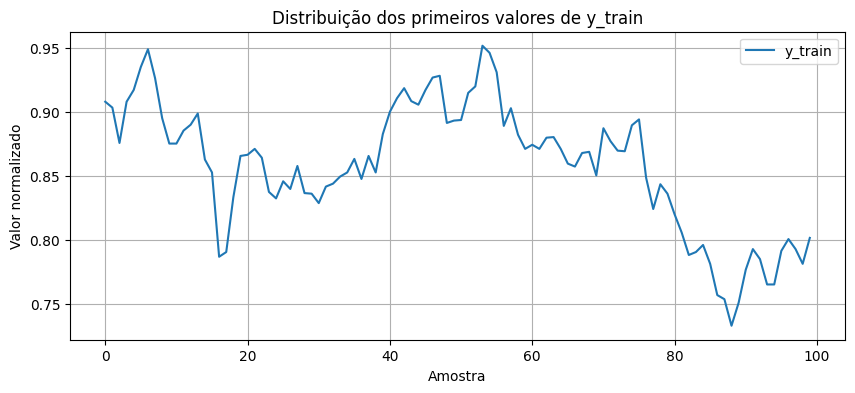

In [21]:
# 🔍 Verificar se y_train tem variação significativa
plt.figure(figsize=(10, 4))
plt.plot(y_train[:100], label='y_train')
plt.title('Distribuição dos primeiros valores de y_train')
plt.xlabel('Amostra')
plt.ylabel('Valor normalizado')
plt.grid()
plt.legend()
plt.show()

### Definição da arquitetura LSTM-GRU

A arquitetura combina uma camada LSTM, voltada à retenção de dependências de maior alcance, com uma camada GRU, responsável por refinar a representação temporal antes da projeção final. Nesta etapa, a preocupação central não é o ajuste fino, mas verificar se a estrutura recorrente consegue extrair sinal preditivo de uma entrada centrada no histórico do preço.


In [22]:
class LSTM_GRU_Model(nn.Module):
    def __init__(self, input_size, hidden_lstm=64, hidden_gru=32):
        super().__init__()

        # 🧠 LSTM: aprende padrões de longo prazo na série temporal
        # input_size: número de features por time step (ex: Close, RSI, EMA...)
        # hidden_lstm: número de neurônios na camada LSTM
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden_lstm, batch_first=True)
        # self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)

        # 🔁 GRU: refina as representações aprendidas pela LSTM
        # Recebe como entrada a saída da LSTM
        self.gru = nn.GRU(input_size=hidden_lstm, hidden_size=hidden_gru, batch_first=True)

        # Camada densa final: transforma o hidden final da GRU em uma predição
        self.fc = nn.Linear(hidden_gru, 1)

    def forward(self, x):

        # LSTM layer
        out_lstm1, _ = self.lstm1(x)  # Shape: (batch, seq_len, hidden_lstm)
        # out_lstm2, _ = self.lstm2(x)  # Shape: (batch, seq_len, hidden_lstm)

        # GRU layer
        out_gru, _ = self.gru(out_lstm1)  # Shape: (batch, seq_len, hidden_gru)
        # out_gru, _ = self.gru(out_lstm2)  # Shape: (batch, seq_len, hidden_gru)

        # Pegamos apenas a última saída temporal
        final_output = self.fc(out_gru[:, -1, :])  # Shape: (batch, 1)

        return final_output


In [23]:
# Detectar número de features automaticamente
input_size = X_train.shape[2]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTM_GRU_Model(input_size=X_train.shape[2]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Feature Learning

O objetivo metodológico deste notebook é validar a capacidade de aprendizado estrutural da rede. Em outras palavras, busca-se observar se a arquitetura consegue sair de um regime puramente linear e aprender padrões relevantes de variância, persistência e direção a partir de uma base informacional mínima.


## Treinamento do modelo

O treinamento é acompanhado por perdas de treino e validação para avaliar convergência e generalização. Somente depois de estabilizar esse aprendizado estrutural faz sentido avançar para a etapa de otimização, na qual hiperparâmetros como `dropout`, `learning rate` e função de perda passam a ser ajustados de forma mais fina.


Epoch  1: Train Loss = 0.025325, Val Loss = 0.001072
Epoch  2: Train Loss = 0.002192, Val Loss = 0.000848
Epoch  3: Train Loss = 0.001523, Val Loss = 0.000320
Epoch  4: Train Loss = 0.001084, Val Loss = 0.000258
Epoch  5: Train Loss = 0.000779, Val Loss = 0.000180
Epoch  6: Train Loss = 0.000605, Val Loss = 0.000689
Epoch  7: Train Loss = 0.000588, Val Loss = 0.000534
Epoch  8: Train Loss = 0.000554, Val Loss = 0.000173
Epoch  9: Train Loss = 0.000536, Val Loss = 0.000129
Epoch 10: Train Loss = 0.000450, Val Loss = 0.000198
Epoch 11: Train Loss = 0.000426, Val Loss = 0.000094
Epoch 12: Train Loss = 0.000481, Val Loss = 0.000116
Epoch 13: Train Loss = 0.000486, Val Loss = 0.000098
Epoch 14: Train Loss = 0.000360, Val Loss = 0.000190
Epoch 15: Train Loss = 0.000469, Val Loss = 0.000106
Epoch 16: Train Loss = 0.000542, Val Loss = 0.000228
Epoch 17: Train Loss = 0.000467, Val Loss = 0.000064
Epoch 18: Train Loss = 0.000377, Val Loss = 0.000092
Epoch 19: Train Loss = 0.000385, Val Loss = 0.

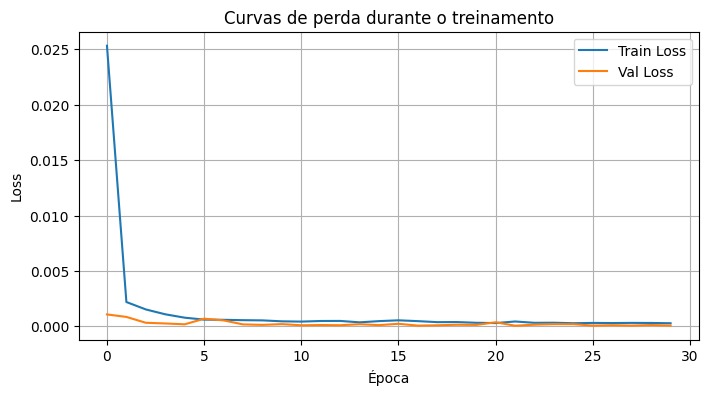

In [24]:
# 🔁 Treinamento com validação por época + melhor modelo salvo
from copy import deepcopy
best_val_loss = float('inf')
best_model_state = None
train_losses, val_losses = [], []

for epoch in range(1, 31):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb).squeeze()
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    # Validação
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).squeeze()
            val_loss = criterion(preds, yb)
            val_batch_losses.append(val_loss.item())
    val_loss = np.mean(val_batch_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:2d}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

    # Salvar melhor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())

# Restaurar melhor modelo após o treinamento
model.load_state_dict(best_model_state)

# Plot das curvas de perda
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Curvas de perda durante o treinamento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

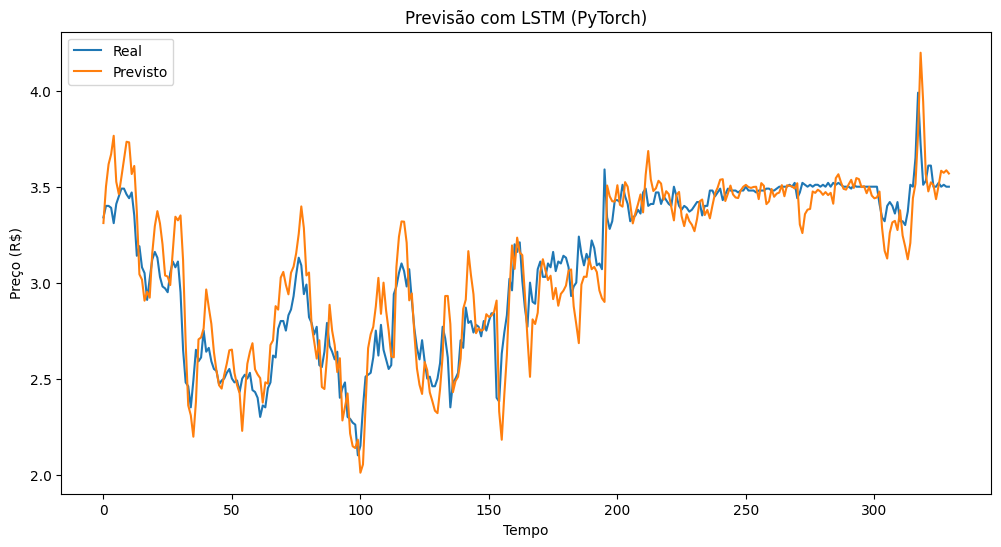

In [25]:
# Avaliação com correção para scaler multivariado
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        out = model(xb)
        preds.extend(out.cpu().numpy())

# Ajustar shape para inverse_transform apenas da feature alvo
preds = np.array(preds)
preds_full = np.zeros((len(preds), scaler.n_features_in_))
actual_full = np.zeros((len(y_test), scaler.n_features_in_))
preds_full[:, 0] = preds[:, 0]
actual_full[:, 0] = y_test

preds_inverse = scaler.inverse_transform(preds_full)[:, 0]
actual_inverse = scaler.inverse_transform(actual_full)[:, 0]

# Plot
plt.figure(figsize=(12,6))
plt.plot(actual_inverse, label='Real')
plt.plot(preds_inverse, label='Previsto')
plt.legend()
plt.title('Previsão com LSTM (PyTorch)')
plt.xlabel('Tempo')
plt.ylabel('Preço (R$)')
plt.show()

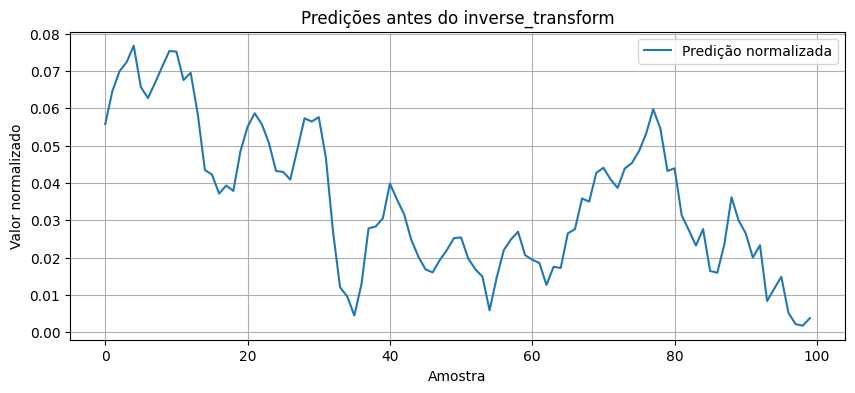

Predição (normalizada) - min: -0.0042, max: 0.0967, média: 0.0456


In [26]:
# 🧪 Diagnóstico: distribuição das predições normalizadas
plt.figure(figsize=(10, 4))
plt.plot(preds[:100], label='Predição normalizada')
plt.title('Predições antes do inverse_transform')
plt.xlabel('Amostra')
plt.ylabel('Valor normalizado')
plt.grid()
plt.legend()
plt.show()

print(f"Predição (normalizada) - min: {preds.min():.4f}, max: {preds.max():.4f}, média: {preds.mean():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


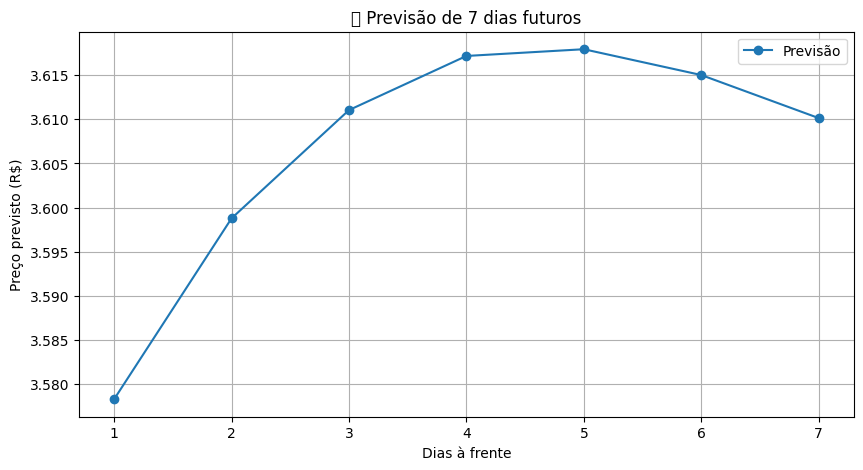

Dia +1: R$ 3.58
Dia +2: R$ 3.60
Dia +3: R$ 3.61
Dia +4: R$ 3.62
Dia +5: R$ 3.62
Dia +6: R$ 3.62
Dia +7: R$ 3.61


In [27]:
# 🧠 Previsão de múltiplos dias à frente
model.eval()
n_future = 7  # número de dias a prever

# Última sequência disponível
last_sequence = data[-seq_len:].values
last_scaled = scaler.transform(last_sequence)
future_preds = []

# Preparar o primeiro input [1, seq_len, n_features]
current_input = torch.tensor(last_scaled, dtype=torch.float32).unsqueeze(0).to(device)

for _ in range(n_future):
    with torch.no_grad():
        next_pred = model(current_input)
        pred_val = next_pred.cpu().numpy()[0, 0]
        future_preds.append(pred_val)

    # Preparar próxima entrada
    # Manter todas as features da última linha, mas sobrescrever o target (índice 0)
    next_step = current_input[0, -1, :].cpu().numpy()
    next_step[0] = pred_val  # Substitui apenas o target
    next_step = next_step.reshape(1, -1)

    # Construir nova sequência deslocando uma posição à frente
    next_sequence = torch.cat([
        current_input[:, 1:, :],  # remove o primeiro dia
        torch.tensor(next_step, dtype=torch.float32).unsqueeze(0).to(device)  # adiciona novo dia
    ], dim=1)

    current_input = next_sequence

# Corrigir estrutura para inverse_transform
future_scaled_full = np.zeros((n_future, scaler.n_features_in_))
future_scaled_full[:, 0] = future_preds  # só preenche a coluna do target

# Inverte e extrai apenas o target original
future_prices = scaler.inverse_transform(future_scaled_full)[:, 0]

# Plot
plt.figure(figsize=(10,5))
plt.plot(range(1, n_future + 1), future_prices, marker='o', label='Previsão')
plt.title('📅 Previsão de 7 dias futuros')
plt.xlabel('Dias à frente')
plt.ylabel('Preço previsto (R$)')
plt.grid()
plt.legend()
plt.show()

# Mostrar os valores
for i, p in enumerate(future_prices):
    print(f"Dia +{i+1}: R$ {p:.2f}")

In [28]:
# ==================================================
# CÉLULA - MÉTRICAS DE AVALIAÇÃO DO MODELO
# ==================================================
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Garantir arrays 1D
y_true = np.array(actual_inverse).reshape(-1)
y_pred = np.array(preds_inverse).reshape(-1)

# ------------------------------------------
# Métricas de regressão
# ------------------------------------------
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

# Evitar divisão por zero no MAPE
mask_mape = y_true != 0
mape = np.mean(np.abs((y_true[mask_mape] - y_pred[mask_mape]) / y_true[mask_mape])) * 100

r2 = r2_score(y_true, y_pred)

# ------------------------------------------
# Métrica direcional
# ------------------------------------------
# Compara se o modelo acertou a direção do movimento
# usando a variação entre t-1 e t
real_diff = np.diff(y_true)
pred_diff = np.diff(y_pred)

direcao_real = np.sign(real_diff)
direcao_pred = np.sign(pred_diff)

directional_accuracy = np.mean(direcao_real == direcao_pred) * 100

# ------------------------------------------
# Baseline ingênua
# ------------------------------------------
# Previsão de hoje = valor de ontem
baseline_pred = y_true[:-1]
baseline_true = y_true[1:]

baseline_mae = mean_absolute_error(baseline_true, baseline_pred)
baseline_mse = mean_squared_error(baseline_true, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)

mask_baseline_mape = baseline_true != 0
baseline_mape = np.mean(
    np.abs((baseline_true[mask_baseline_mape] - baseline_pred[mask_baseline_mape]) / baseline_true[mask_baseline_mape])
) * 100

baseline_r2 = r2_score(baseline_true, baseline_pred)

baseline_real_diff = np.diff(baseline_true)
baseline_pred_diff = np.diff(baseline_pred)

baseline_directional_accuracy = np.mean(
    np.sign(baseline_real_diff) == np.sign(baseline_pred_diff)
) * 100

# ------------------------------------------
# Tabela resumo
# ------------------------------------------
metricas = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "MAPE (%)", "R²", "Directional Accuracy (%)"],
    "LSTM": [mae, mse, rmse, mape, r2, directional_accuracy],
    "Baseline Ingênua": [
        baseline_mae,
        baseline_mse,
        baseline_rmse,
        baseline_mape,
        baseline_r2,
        baseline_directional_accuracy
    ]
})

print("=== MÉTRICAS DO MODELO ===")
display(metricas)

# ------------------------------------------
# Interpretação simples
# ------------------------------------------
print("Resumo rápido:")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.6f}")
print(f"Dir. Accuracy: {directional_accuracy:.2f}%")

=== MÉTRICAS DO MODELO ===


,Métrica,LSTM,Baseline Ingênua
0,MAE,0.119856,0.062006
1,MSE,0.026524,0.009040
2,RMSE,0.162860,0.095080
3,MAPE (%),4.076168,2.130905
4,R²,0.838134,0.944926
5,Directional Accuracy (%),40.729483,39.939024


Resumo rápido:
MAE  : 0.119856
RMSE : 0.162860
MAPE : 4.08%
R²   : 0.838134
Dir. Accuracy: 40.73%
